In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

# Data Exploration

In [2]:
df_path = '../datasets/Iris.csv'

iris = pd.read_csv(df_path)

In [3]:
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
iris.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [6]:
iris.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

# Data Visualization

Text(0, 0.5, 'SepalWidthCm')

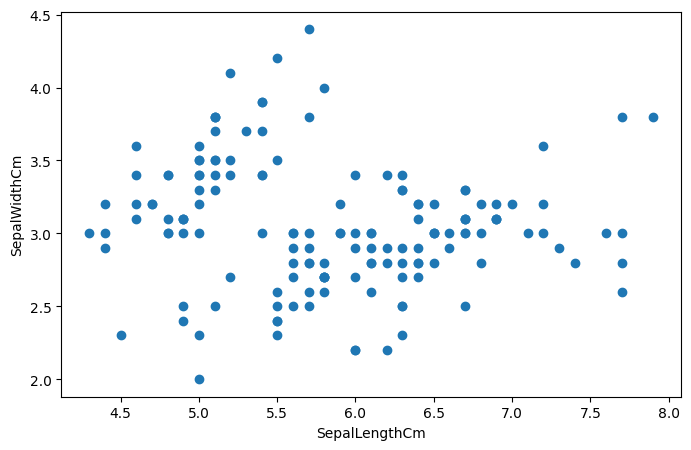

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(iris['SepalLengthCm'], iris['SepalWidthCm'])
plt.xlabel('SepalLengthCm')
plt.ylabel('SepalWidthCm')

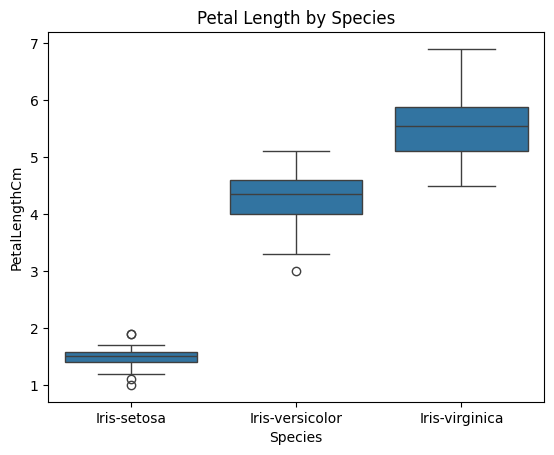

In [23]:
sns.boxplot(
    x='Species',
    y='PetalLengthCm',
    data=iris
)

plt.title('Petal Length by Species')
plt.show()

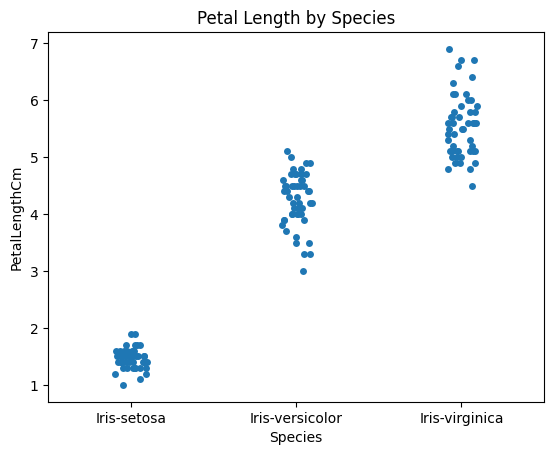

In [130]:
sns.stripplot(
    x='Species',
    y='PetalLengthCm',
    data=iris
)

plt.title('Petal Length by Species')
plt.show()

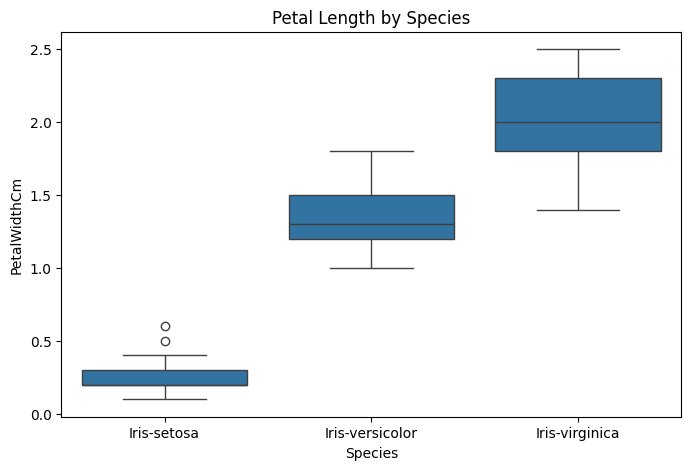

In [9]:
sns.boxplot(
    x='Species',
    y='PetalWidthCm',
    data=iris
)

plt.title('Petal Length by Species')
plt.show()

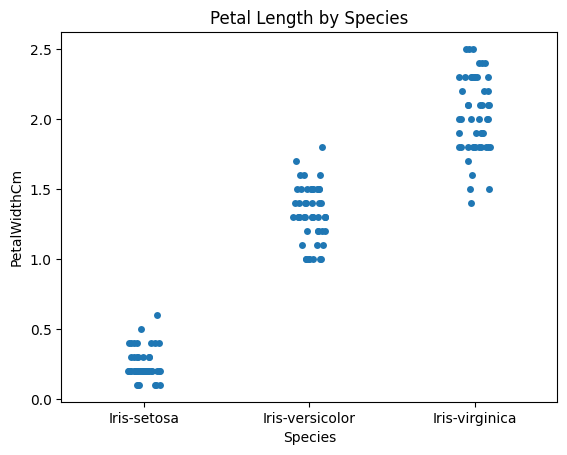

In [131]:
sns.stripplot(
    x='Species',
    y='PetalWidthCm',
    data=iris
)

plt.title('Petal Length by Species')
plt.show()

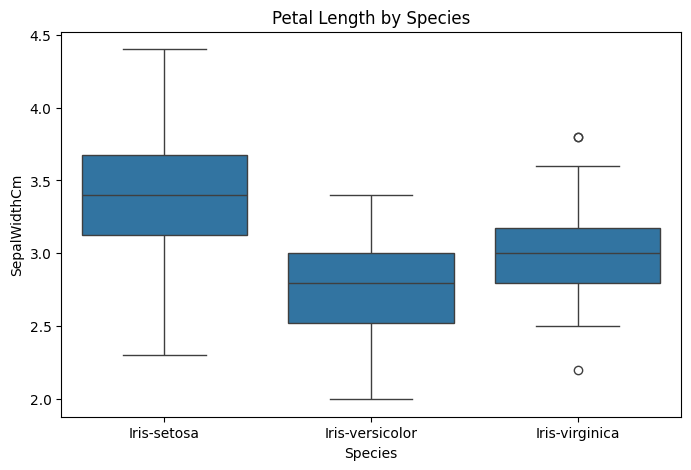

In [10]:
sns.boxplot(
    x='Species',
    y='SepalWidthCm',
    data=iris
)

plt.title('Petal Length by Species')
plt.show()

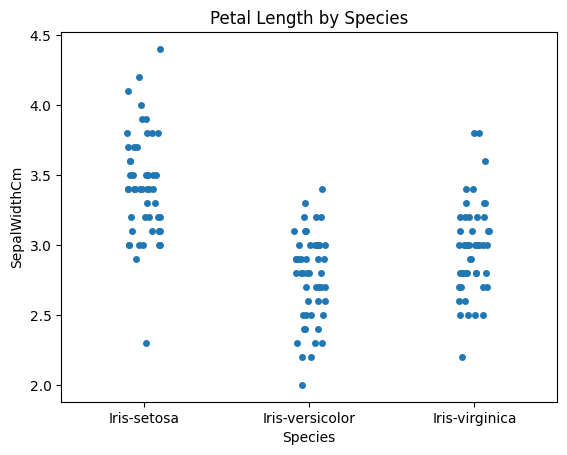

In [132]:
sns.stripplot(
    x='Species',
    y='SepalWidthCm',
    data=iris
)

plt.title('Petal Length by Species')
plt.show()

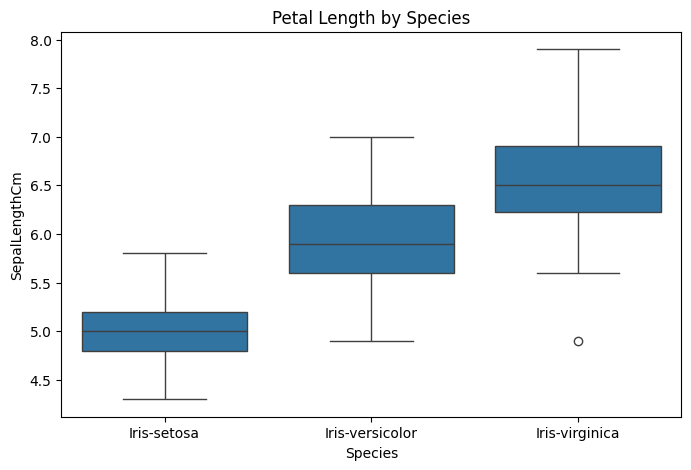

In [11]:
sns.boxplot(
    x='Species',
    y='SepalLengthCm',
    data=iris
)

plt.title('Petal Length by Species')
plt.show()

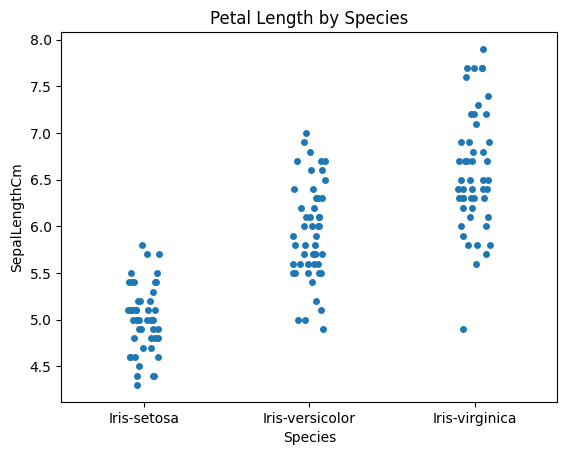

In [129]:
sns.stripplot(
    x='Species',
    y='SepalLengthCm',
    data=iris
)

plt.title('Petal Length by Species')
plt.show()

D:\downloads\Code\Utility\colab\venv\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


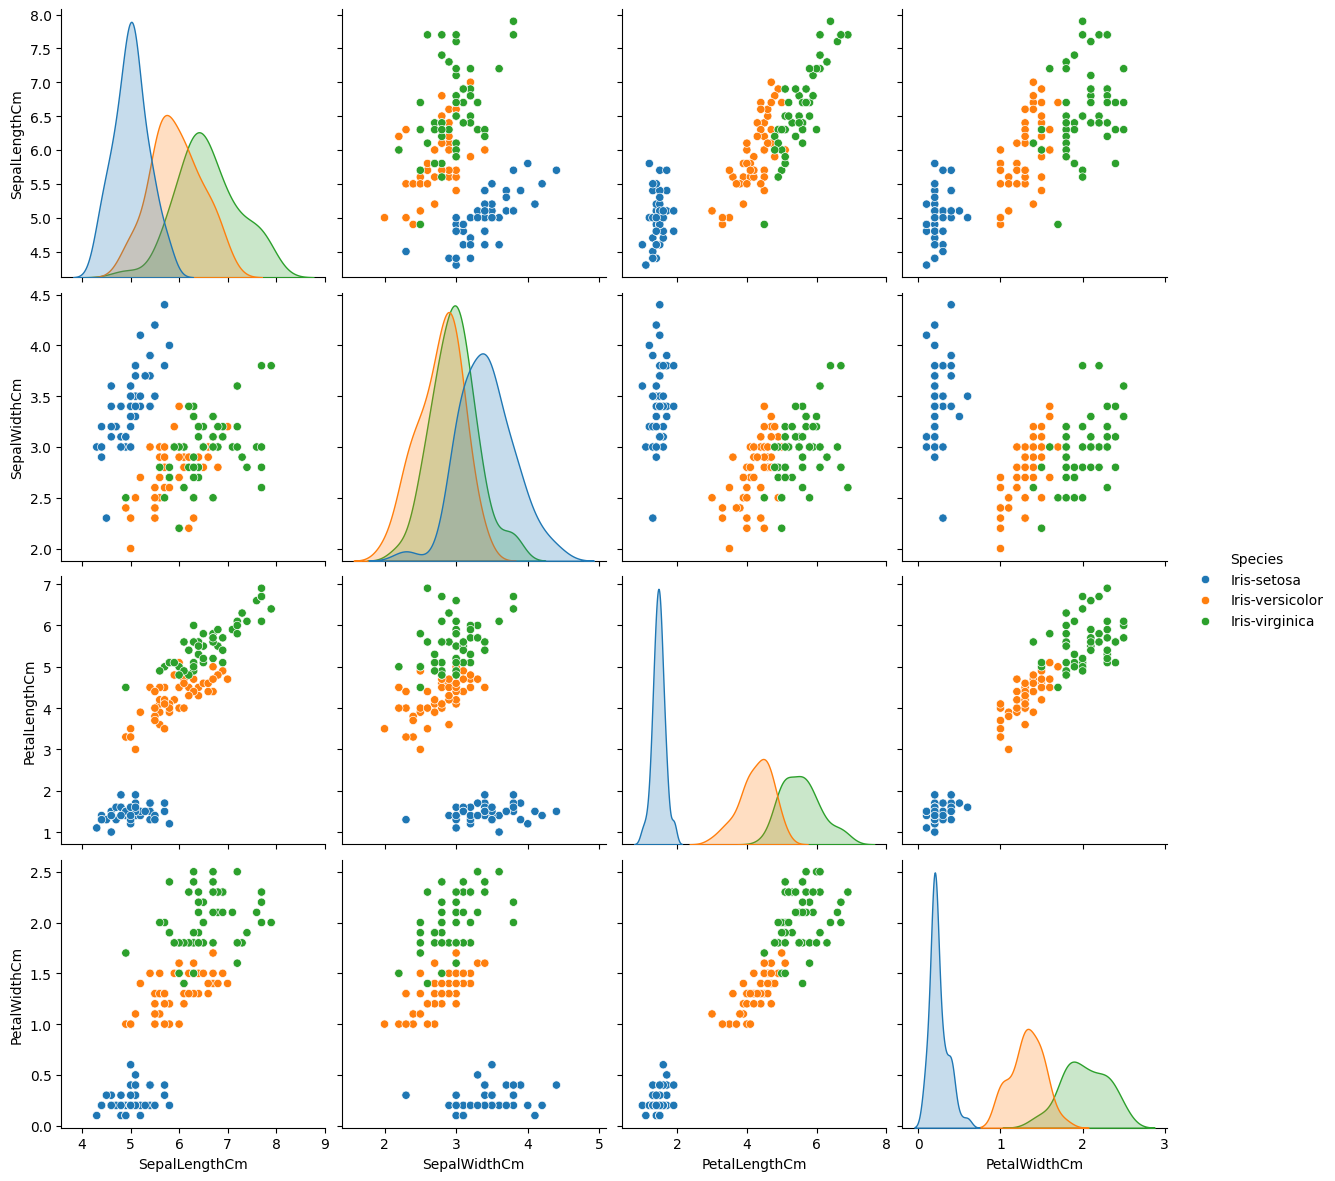

In [13]:
sns.pairplot(iris.drop("Id", axis=1), hue='Species', size = 3)

In [26]:
X = iris[['SepalLengthCm','SepalWidthCm','PetalLengthCm', 'PetalWidthCm',]]

In [27]:
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


# Data Scaling

In [28]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [76]:
X_scaled_df = pd.DataFrame(X_scaled, columns=['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm'])

In [77]:
X_scaled_df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667
...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667
146,0.555556,0.208333,0.677966,0.750000
147,0.611111,0.416667,0.711864,0.791667
148,0.527778,0.583333,0.745763,0.916667


In [69]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

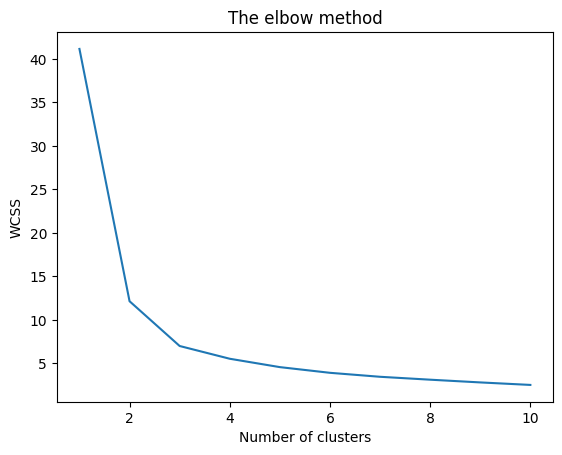

In [70]:
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [71]:
sil_scores = []

K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k,random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_df)
    score = silhouette_score(X_scaled_df, labels)
    sil_scores.append(score)

sil_scores

[0.6294675561906644,
 0.5043188549150884,
 0.4446273300650682,
 0.35538315267369003,
 0.3592519367094377,
 0.34728549140994325,
 0.33449099740364696,
 0.3193794548863887,
 0.33709060550981673]

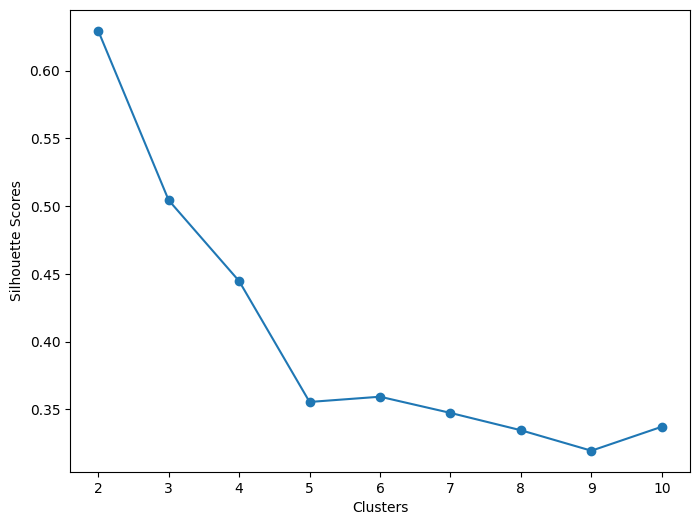

In [72]:
plt.figure(figsize=(8,6))
plt.plot(K, sil_scores, marker='o')
plt.xlabel('Clusters')
plt.ylabel('Silhouette Scores')
plt.show()

# K-Means Clustering

In [75]:
kmeans = KMeans(n_clusters = 3, max_iter = 300, n_init = 10, random_state = 0)
y_kmeans = kmeans.fit_predict(X_scaled_df)

In [74]:
y_kmeans

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [39]:
np.unique(y_kmeans)

array([0, 1, 2], dtype=int32)

In [81]:
X['y_kmeans'] = y_kmeans.copy()

In [82]:
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,y_kmeans
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,0
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [48]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers

array([[5.88852459, 2.73770492, 4.39672131, 1.41803279],
       [5.006     , 3.418     , 1.464     , 0.244     ],
       [6.84615385, 3.08205128, 5.7025641 , 2.07948718]])

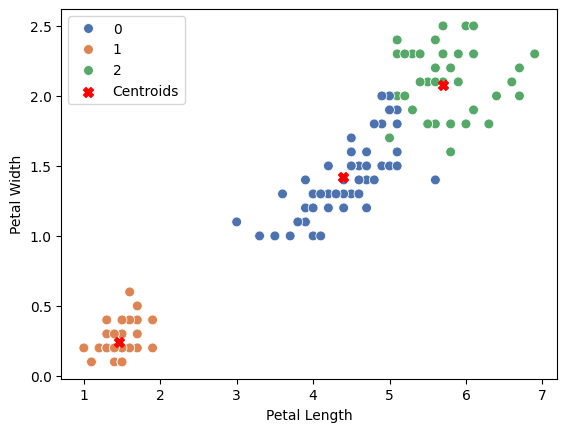

In [63]:
sns.scatterplot(
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='y_kmeans',
    palette='deep',
    s=50,
    data=X
)
plt.scatter(centers[:,2],centers[:,3], marker='X',s = 50, c = 'red', label = 'Centroids')

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.legend()

In [89]:
silhouette_score(X, y_kmeans, metric='euclidean')

0.6837381063174701

# K-Distance Graph

In [93]:
neighbors = NearestNeighbors(n_neighbors=20)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

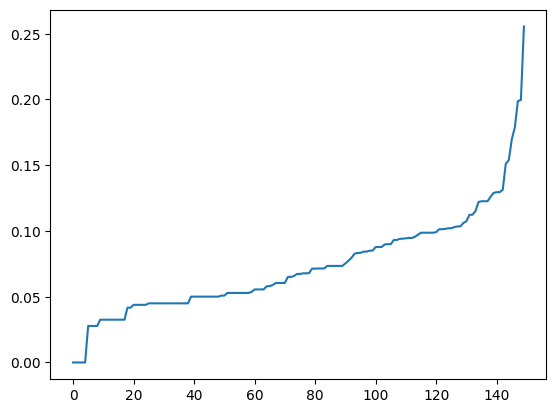

In [94]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)

# DBSCAN

In [106]:
dbscan = DBSCAN(
    eps = 0.14,
    min_samples=10
)

y_dbscan = dbscan.fit_predict(X_scaled)

In [108]:
X['y_dbscan']=y_dbscan.copy()

In [109]:
np.unique(y_dbscan)

array([-1,  0,  1,  2])

In [112]:
outliers = X[X['y_dbscan']==-1]

In [119]:
outliers.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,y_kmeans,y_dbscan
14,5.8,4.0,1.2,0.2,1,-1
15,5.7,4.4,1.5,0.4,1,-1
33,5.5,4.2,1.4,0.2,1,-1
41,4.5,2.3,1.3,0.3,1,-1
56,6.3,3.3,4.7,1.6,0,-1


In [120]:
plot_X = X[X['y_dbscan']>=0]

<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

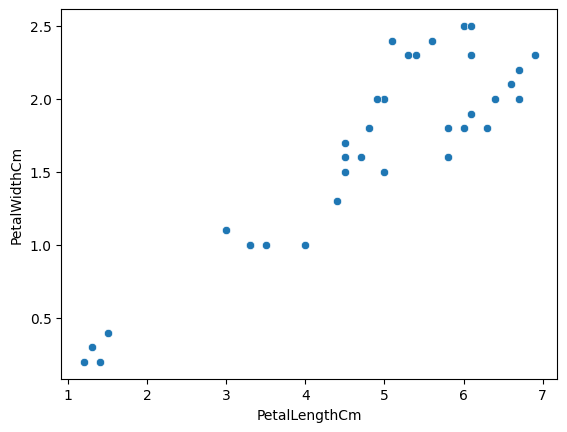

In [122]:
sns.scatterplot(
    x='PetalLengthCm',
    y='PetalWidthCm',
    data=outliers
)

<Axes: xlabel='PetalLengthCm', ylabel='SepalLengthCm'>

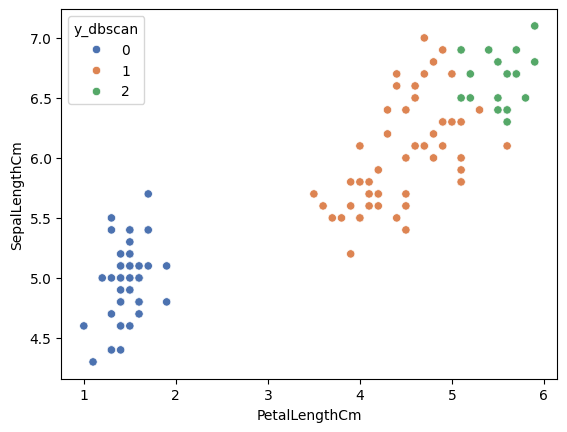

In [128]:
sns.scatterplot(
    x='PetalLengthCm',
    y='SepalLengthCm',
    hue='y_dbscan',
    palette='deep',
    data=plot_X
)